### Imports

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib
import sys
sys.path.append('/teamspace/studios/this_studio/Human-Activity-Recognition')
from src.gru import build_gru
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import os

### Load & Preprocess Raw Sensor Data

In [2]:
sensor_names = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',     # Accelerometer measurements
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',  # Gyroscope measurements
    'total_acc_x', 'total_acc_y', 'total_acc_z'     # Raw accelerometer measurements before filtering (total acceleration)
]

def load_data(split_type):
    signals = []

    for sensor_name in sensor_names:
        file_path = os.path.join(f'../../data/UCI HAR Dataset/{split_type}/Inertial Signals/{sensor_name}_{split_type}.txt')
        signal = np.array(pd.read_csv(file_path, delim_whitespace=True, header=None).values)
        signals.append(signal)

    return np.array(signals).transpose(1, 2, 0)

def load_labels(split_type):
    file_path = os.path.join(f'../../data/UCI HAR Dataset/{split_type}/y_{split_type}.txt')
    # Convert 1 - 6 to 0 - 5
    return pd.read_csv(file_path, delim_whitespace=True, header=None).values.flatten() - 1


def normalize_data(X_train_raw, X_test_raw):
    n_samples_train, n_timesteps, n_features = X_train_raw.shape
    n_samples_test = X_test_raw.shape[0]

    # Reshape to (samples * timesteps, features) so scaler sees each feature
    X_train_flat = X_train_raw.reshape(-1, n_features)
    X_test_flat  = X_test_raw.reshape(-1, n_features)

    # Fit on training data only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled  = scaler.transform(X_test_flat)

    # Reshape back to (samples, timesteps, features)
    X_train_norm = X_train_scaled.reshape(n_samples_train, n_timesteps, n_features)
    X_test_norm  = X_test_scaled.reshape(n_samples_test,  n_timesteps, n_features)

    return X_train_norm, X_test_norm, scaler

X_train_raw = load_data('train')
X_test_raw = load_data('test')
y_train = load_labels('train')
y_test = load_labels('test')
X_train_norm, X_test_norm, scaler = normalize_data(X_train_raw, X_test_raw)

### Build & Train The GRU Model

In [3]:
model = build_gru()
model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

history = model.fit(
    X_train_norm, y_train_categorical,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ModelCheckpoint('../../models/gru.h5', monitor='val_loss', save_best_only=True)
    ]
)

test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_categorical, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

E0000 00:00:1780915672.633013  153343 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Fast_GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,206 (75.02 KB)

 Trainable params: 19,078 (74.52 KB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.7150 - loss: 0.6698 - val_accuracy: 0.8151 - val_loss: 0.6026
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7902 - loss: 0.5068

92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8113 - loss: 0.4675 - val_accuracy: 0.8770 - val_loss: 0.4142
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8641 - loss: 0.3503

92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.8869 - loss: 0.3104 - val_accuracy: 0.8912 - val_loss: 0.2572
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9182 - loss: 0.2047

92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9281 - loss: 0.1892 - val_accuracy: 0.9361 - val_loss: 0.2413
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9463 - loss: 0.1459 - val_accuracy: 0.9313 - val_loss: 0.2490
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.9478 - loss: 0.1387 - val_accuracy: 0.9232 - val_loss: 0.2607
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9498 - loss: 0.1471

92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9500 - loss: 0.1386 - val_accuracy: 0.9375 - val_loss: 0.2164
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.9541 - loss: 0.1158 - val_accuracy: 0.9368 - val_loss: 0.2190
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9583 - loss: 0.1134 - val_accuracy: 0.9279 - val_loss: 0.2432
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9558 - loss: 0.1108 - val_accuracy: 0.9157 - val_loss: 0.2733
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9534 - loss: 0.1087 - val_accuracy: 0.9191 - val_loss: 0.2625
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9514 - loss: 0.1164 - val_accuracy: 0.9035 - val_loss: 0.3428
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9592 - loss: 0.1003 - val_accuracy: 0.9116 - val_loss: 0.3062
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.9572 - loss: 0.1025 - val_accuracy: 0.9082 - val_lo

### Plots

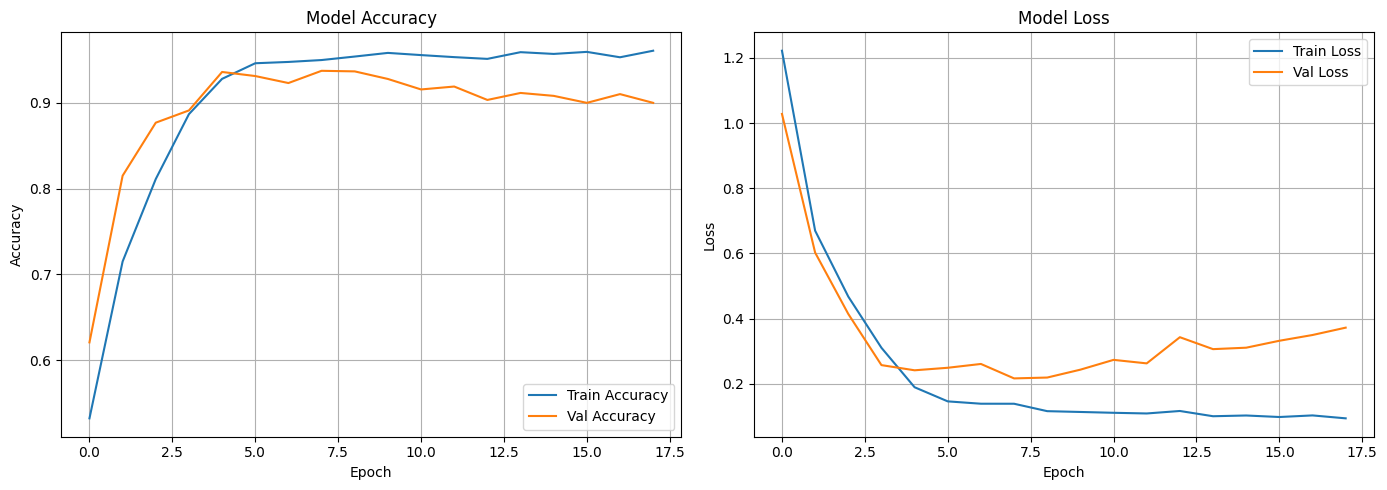

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()